In [ ]:
!pip install -q transformers torch deep-translator emoji

In [ ]:
import pandas as pd
import emoji
from deep_translator import GoogleTranslator
from transformers import pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = ("/content/drive/MyDrive/Datasets CSV/Rahul Gandhi Instagram Comment.csv")

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.head(40)

,Unnamed: 0,Unnamed: 1,Name,Username,Profile ID,Date,Likes,Comment,User Verified,Thumbnail,Comment ID,Profile URL,Comment URL
0,1,NaN,harshvardhanraj38,harshvardhanraj38,77766916107,2026-06-18 15:31:23,0,"🚨BIHAR: They leak papers, destroying our futur...",no,https://instagram.fada1-15.fna.fbcdn.net/v/t51...,17985759350866460,https://www.instagram.com/harshvardhanraj38,https://www.instagram.com/p/DZuvFYICrz1/c/1798...
1,2,NaN,shahana4386,shahana4386,8525416279,2026-06-18 15:31:35,0,❤️❤️❤️❤️,no,https://scontent-eze1-2.cdninstagram.com/v/t51...,18124882330653790,https://www.instagram.com/shahana4386,https://www.instagram.com/p/DZuvFYICrz1/c/1812...
2,3,NaN,aryan_bihari_0047,aryan_bihari_0047,50687490153,2026-06-18 15:32:04,0,❤️❤️,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,17933370858290684,https://www.instagram.com/aryan_bihari_0047,https://www.instagram.com/p/DZuvFYICrz1/c/1793...
3,4,NaN,sinchana8170,sinchana8170,47658405812,2026-06-18 15:32:13,0,This is why gen z love rahul Gandhi ❤️❤️❤️❤️❤️,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,18394436935095912,https://www.instagram.com/sinchana8170,https://www.instagram.com/p/DZuvFYICrz1/c/1839...
4,5,NaN,niteshsrivastava814,niteshsrivastava814,27476085056,2026-06-18 15:32:20,0,👏👏👏👏👏👏👏,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,18076435382454548,https://www.instagram.com/niteshsrivastava814,https://www.instagram.com/p/DZuvFYICrz1/c/1807...
5,6,NaN,19saanjh,19saanjh,7404278604,2026-06-18 15:32:29,0,🔥Raga 🔥,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,18089160476376159,https://www.instagram.com/19saanjh,https://www.instagram.com/p/DZuvFYICrz1/c/1808...
6,7,NaN,vinuu_vinuu_honey,vinuu_vinuu_honey,78526891629,2026-06-18 15:32:32,0,💗💝👑 Rahul Sir Sooo Sooo Sooo Much Sweet Person...,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,17867617386688703,https://www.instagram.com/vinuu_vinuu_honey,https://www.instagram.com/p/DZuvFYICrz1/c/1786...
7,8,NaN,elizabethann.smith.9022,elizabethann.smith.9022,51403342145,2026-06-18 15:32:47,0,Next Prime Minister Of India Rahul Gandhi ji Z...,no,https://scontent-eze1-2.cdninstagram.com/v/t51...,18085802558415179,https://www.instagram.com/elizabethann.smith.9022,https://www.instagram.com/p/DZuvFYICrz1/c/1808...
8,9,NaN,shanupooransingh,shanupooransingh,45414303657,2026-06-18 15:32:49,0,❤️❤️❤️❤️,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,18139616911561921,https://www.instagram.com/shanupooransingh,https://www.instagram.com/p/DZuvFYICrz1/c/1813...
9,10,NaN,vinuu_vinuu_honey,vinuu_vinuu_honey,78526891629,2026-06-18 15:32:58,0,💗💝👑 Rahul Sir Sooo Sooo Sweet Lovely Iconic Le...,no,https://scontent-eze1-1.cdninstagram.com/v/t51...,18119797558688350,https://www.instagram.com/vinuu_vinuu_honey,https://www.instagram.com/p/DZuvFYICrz1/c/1811...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     100 non-null    int64  
 1   Unnamed: 1     0 non-null      float64
 2   Name           100 non-null    object 
 3   Username       100 non-null    object 
 4   Profile ID     100 non-null    int64  
 5   Date           100 non-null    object 
 6   Likes          100 non-null    int64  
 7   Comment        90 non-null     object 
 8   User Verified  100 non-null    object 
 9   Thumbnail      100 non-null    object 
 10  Comment ID     100 non-null    int64  
 11  Profile URL    100 non-null    object 
 12  Comment URL    100 non-null    object 
dtypes: float64(1), int64(4), object(8)
memory usage: 10.3+ KB


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Unnamed: 1,100
Name,0
Username,0
Profile ID,0
Date,0
Likes,0
Comment,10
User Verified,0
Thumbnail,0


In [ ]:
col = ["Unnamed: 0","Unnamed: 1","Profile ID","User Verified","Thumbnail","Comment ID","Profile URL","Comment URL","Likes"]

In [ ]:
df.drop(columns = col, inplace = True)

In [ ]:
df.head()

,Name,Username,Date,Comment
0,harshvardhanraj38,harshvardhanraj38,2026-06-18 15:31:23,"🚨BIHAR: They leak papers, destroying our futur..."
1,shahana4386,shahana4386,2026-06-18 15:31:35,❤️❤️❤️❤️
2,aryan_bihari_0047,aryan_bihari_0047,2026-06-18 15:32:04,❤️❤️
3,sinchana8170,sinchana8170,2026-06-18 15:32:13,This is why gen z love rahul Gandhi ❤️❤️❤️❤️❤️
4,niteshsrivastava814,niteshsrivastava814,2026-06-18 15:32:20,👏👏👏👏👏👏👏


In [ ]:
#Drop null
df.dropna(inplace=True)

In [ ]:
#Load RoBERTa Model
classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#Emoji to Text
def convert_emoji(text):
    return emoji.demojize(str(text))

In [ ]:
#Translation Function
def translate_text(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except:
        return text

In [ ]:
#Sentiment Function
POSITIVE_EMOJIS = [
    ":red_heart:",
    ":heart:",
    ":growing_heart:",
    ":heart_with_ribbon:",
    ":smiling_face_with_heart-eyes:",
    ":clapping_hands:",
    ":fire:",
    ":raising_hands:",
    ":hundred_points:",
    ":crown:"
]

def predict_sentiment(text):

    text = str(text)

    # Emoji rule
    if any(e in text for e in POSITIVE_EMOJIS):
        return "Positive"

    result = classifier(
        text,
        truncation=True,
        max_length=512
    )[0]

    label = result["label"].lower()

    if label == "positive":
        return "Positive"
    elif label == "negative":
        return "Negative"
    else:
        return "Neutral"

In [ ]:
#Apply Emoji Conversion
df["Emoji_Text"] = df["Comment"].apply(convert_emoji)

In [ ]:
#Translate Comments
df["Translated"] = df["Emoji_Text"].apply(translate_text)

In [ ]:
#Sentiment Analysis
df["Sentiment"] = df["Translated"].apply(predict_sentiment)

In [ ]:
df.head(40)

,Name,Username,Date,Comment,Emoji_Text,Translated,Sentiment
0,harshvardhanraj38,harshvardhanraj38,2026-06-18 15:31:23,"🚨BIHAR: They leak papers, destroying our futur...",":police_car_light:BIHAR: They leak papers, des...",":police_car_light:BIHAR: They leak papers, des...",Negative
1,shahana4386,shahana4386,2026-06-18 15:31:35,❤️❤️❤️❤️,:red_heart::red_heart::red_heart::red_heart:,:red_heart::red_heart::red_heart::red_heart:,Positive
2,aryan_bihari_0047,aryan_bihari_0047,2026-06-18 15:32:04,❤️❤️,:red_heart::red_heart:,:red_heart::red_heart:,Positive
3,sinchana8170,sinchana8170,2026-06-18 15:32:13,This is why gen z love rahul Gandhi ❤️❤️❤️❤️❤️,This is why gen z love rahul Gandhi :red_heart...,This is why gen z love rahul Gandhi :red_heart...,Positive
4,niteshsrivastava814,niteshsrivastava814,2026-06-18 15:32:20,👏👏👏👏👏👏👏,:clapping_hands::clapping_hands::clapping_hand...,:clapping_hands::clapping_hands::clapping_hand...,Positive
5,19saanjh,19saanjh,2026-06-18 15:32:29,🔥Raga 🔥,:fire:Raga :fire:,:fire:Raga :fire:,Positive
6,vinuu_vinuu_honey,vinuu_vinuu_honey,2026-06-18 15:32:32,💗💝👑 Rahul Sir Sooo Sooo Sooo Much Sweet Person...,:growing_heart::heart_with_ribbon::crown: Rahu...,:growing_heart::heart_with_ribbon::crown: Rahu...,Positive
7,elizabethann.smith.9022,elizabethann.smith.9022,2026-06-18 15:32:47,Next Prime Minister Of India Rahul Gandhi ji Z...,Next Prime Minister Of India Rahul Gandhi ji Z...,Next Prime Minister Of India Rahul Gandhi ji Z...,Positive
8,shanupooransingh,shanupooransingh,2026-06-18 15:32:49,❤️❤️❤️❤️,:red_heart::red_heart::red_heart::red_heart:,:red_heart::red_heart::red_heart::red_heart:,Positive
9,vinuu_vinuu_honey,vinuu_vinuu_honey,2026-06-18 15:32:58,💗💝👑 Rahul Sir Sooo Sooo Sweet Lovely Iconic Le...,:growing_heart::heart_with_ribbon::crown: Rahu...,:growing_heart::heart_with_ribbon::crown: Rahu...,Positive


In [ ]:
#Summary
print(df["Sentiment"].value_counts())

Sentiment
Positive    71
Neutral     15
Negative     4
Name: count, dtype: int64


In [ ]:
#Percentage
percentage = df["Sentiment"].value_counts(normalize=True) * 100

print(percentage)

Sentiment
Positive    78.888889
Neutral     16.666667
Negative     4.444444
Name: proportion, dtype: float64


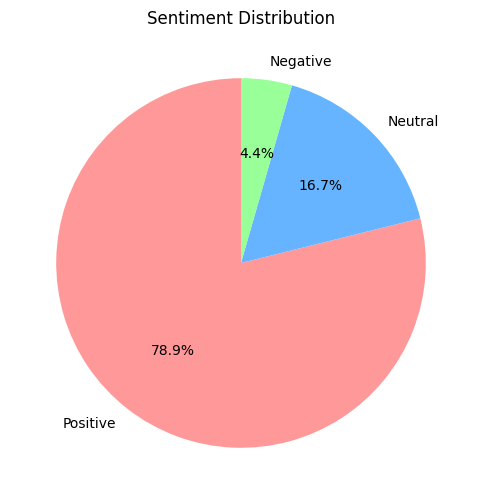

In [ ]:
import matplotlib.pyplot as plt

counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff9999","#66b3ff","#99ff99"]
)

plt.title("Sentiment Distribution")

plt.show()

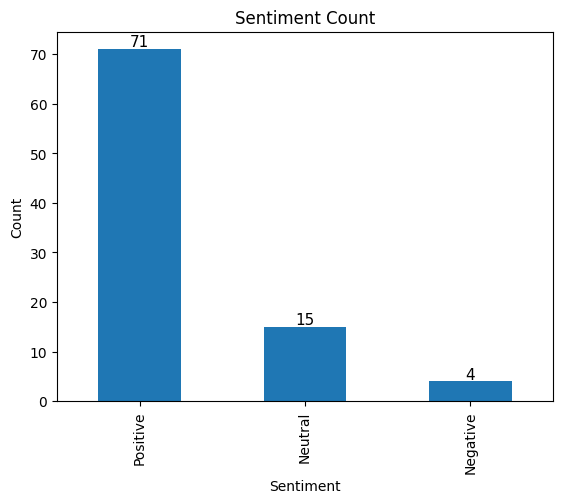

In [ ]:
counts.plot(kind="bar")

plt.title("Sentiment Count")

plt.xlabel("Sentiment")

plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.show()